# ExRec Logical Error Distribution

Syndrome-conditioned logical error analysis for the `[[5,1,3]]` code.

**Circuit model (simplified exRec):**

```
Q_{s_in} · E_fault ──► EC (with syndrome noise) ──► (L, s_out)
```

- `s_in` — input syndrome carried from previous circuitry
- `E_fault` — accumulated Pauli error on the data qubits
- `syndrome_error` — classical bit-flip noise on the measured syndrome
- `L` — resulting logical error class {I, X, Y, Z}
- `s_out` — output syndrome

**Two Monte Carlo models are compared:**
1. **Original MC** — 3 fault locations with depolarizing noise, using the full exRec circuit
2. **New MC** — 2 depolarizing Paulis multiplied into a single fault path, plus independent syndrome bit-flip noise (rate `q`)

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from pauli_utils import (
    LOGICAL_NAMES,
    pauli_str, str_to_pauli, pauli_weight, all_n_qubit_paulis,
    gate_identity, gate_hadamard, gate_phase_S, gate_phase_Sdg, make_custom_gate,
)
from StabilizerCode import StabilizerCode


## 1. Code Definition

In [55]:

code_513 = StabilizerCode(
    n=5,
    generators=[
        (np.array([1,0,0,1,0]), np.array([0,1,1,0,0])),  # g1: XZZXI
        (np.array([0,1,0,0,1]), np.array([0,0,1,1,0])),  # g2: IXZZX
        (np.array([1,0,1,0,0]), np.array([0,0,0,1,1])),  # g3: XIXZZ
        (np.array([0,1,0,1,0]), np.array([1,0,0,0,1])),  # g4: ZXIXZ
    ],
    logical_x=(np.array([1,1,1,1,1]), np.array([0,0,0,0,0])),  # XXXXX
    logical_z=(np.array([0,0,0,0,0]), np.array([1,1,1,1,1])),  # ZZZZZ
    name='[[5,1,3]]',
)

code_713 = StabilizerCode(
    n = 7,
    generators = [
        (np.array([1,1,1,1,0,0,0]), np.array([0,0,0,0,0,0,0])), # g1: XXXXIII
        (np.array([1,1,0,0,1,1,0]), np.array([0,0,0,0,0,0,0])), # g2: XXIIXX I
        (np.array([1,0,1,0,1,0,1]), np.array([0,0,0,0,0,0,0])), # g3: XIXIXIX
        (np.array([0,0,0,0,0,0,0]), np.array([1,1,1,1,0,0,0])), # g4: ZZZZIII
        (np.array([0,0,0,0,0,0,0]), np.array([1,1,0,0,1,1,0])), # g5: ZZIIZZI
        (np.array([0,0,0,0,0,0,0]), np.array([1,0,1,0,1,0,1])), # g6: ZIZIZIZ
    ],
    logical_x=(np.array([1,1,1,1,1,1,1]), np.array([0,0,0,0,0,0,0])), # X̄ = XXXXXXX
    logical_z=(np.array([0,0,0,0,0,0,0]), np.array([1,1,1,1,1,1,1])), # Z̄ = ZZZZZZZ
    name='[[7,1,3]]',
)

code_913 = StabilizerCode(
    n = 9,
    generators = [
        # X-type: phase-flip detection across blocks
        (np.array([1,1,1,1,1,1,0,0,0]), np.array([0,0,0,0,0,0,0,0,0])), # g1: XXXXXXIII
        (np.array([0,0,0,1,1,1,1,1,1]), np.array([0,0,0,0,0,0,0,0,0])), # g2: IIIXXXXXXX
        # Z-type: bit-flip detection within each block
        (np.array([0,0,0,0,0,0,0,0,0]), np.array([1,1,0,0,0,0,0,0,0])), # g3: ZZIIIIIII
        (np.array([0,0,0,0,0,0,0,0,0]), np.array([1,0,1,0,0,0,0,0,0])), # g4: ZIZIIIIII
        (np.array([0,0,0,0,0,0,0,0,0]), np.array([0,0,0,1,1,0,0,0,0])), # g5: IIIЗЗIIII
        (np.array([0,0,0,0,0,0,0,0,0]), np.array([0,0,0,1,0,1,0,0,0])), # g6: IIIZIZIII
        (np.array([0,0,0,0,0,0,0,0,0]), np.array([0,0,0,0,0,0,1,1,0])), # g7: IIIIIIЗZI
        (np.array([0,0,0,0,0,0,0,0,0]), np.array([0,0,0,0,0,0,1,0,1])), # g8: IIIIIIЗIZ
    ],
    logical_x=(np.array([1,1,1,1,1,1,1,1,1]), np.array([0,0,0,0,0,0,0,0,0])), # X̄ = XXXXXXXXX
    logical_z=(np.array([0,0,0,0,0,0,0,0,0]), np.array([1,0,0,1,0,0,1,0,0])), # Z̄ = ZIIZIIЗII
    name='[[9,1,3]]',
)


## 2. Core Functions

All function definitions are collected here. Run these cells once before any simulation.

### 2.1 Error Correction Logic

`get_logical_error` is the central function. Given an input syndrome `s_in`, a single accumulated Pauli error `fault_path`, and a syndrome measurement error bitstring, it propagates through one round of EC and returns the logical error class and output syndrome.

`syndrome_flip` models classical bit-flip noise: the measured syndrome is XORed with `syndrome_error` before the decoder looks up its correction.

In [56]:
def syndrome_flip(s, syndrome_error):
    """XOR syndrome integer s with a binary string syndrome_error."""
    new_s = bin(s ^ int(syndrome_error, 2))[2:].zfill(len(syndrome_error))
    return int(new_s, 2)


def get_logical_error(code, s_in, fault_path, syndrome_error):
    """
    Compute logical error and output syndrome for one simplified exRec.

    Parameters
    ----------
    code            : StabilizerCode
    s_in            : int — input syndrome
    fault_path      : (xvec, zvec) — accumulated n-qubit Pauli error before EC
    syndrome_error  : str — bitstring indicating which syndrome bits are flipped
                      e.g. "0010" flips the 3rd bit

    Returns
    -------
    L     : int  (0=I, 1=X, 2=Y, 3=Z)
    s_out : int  output syndrome
    """
    # Start with Q_{s_in} (min-weight correction for incoming syndrome)
    Qx, Qz = code.corrections[s_in]
    xE, zE = Qx.copy(), Qz.copy()

    # Multiply fault error onto Q_{s_in}
    xf0, zf0 = fault_path
    xE, zE = xE ^ xf0, zE ^ zf0

    # EC: measure syndrome, apply bit-flip noise, then correct
    s_mid = code.compute_syndrome(xE, zE)
    s_error = syndrome_flip(s_mid, syndrome_error)
    Cx, Cz = code.corrections[s_error]
    xE, zE = xE ^ Cx, zE ^ Cz

    # Determine output syndrome and logical class
    s_out = code.compute_syndrome(xE, zE)
    Rx, Rz = code.corrections[s_out]
    xRes, zRes = xE ^ Rx, zE ^ Rz
    L, _ = code.logical_class(xRes, zRes)

    return L, s_out

### 2.2 Sampling Functions

`sample_depolarizing_pauli` draws one random n-qubit Pauli from the independent depolarizing channel: each qubit gets X, Y, or Z each with probability `p/3`, and I with probability `1 - p`.

`sample_syndrome_error` generates a random syndrome-noise bitstring where each bit flips independently with probability `q`.

In [57]:
def sample_depolarizing_pauli(n, p, rng):
    """Sample one n-qubit Pauli under independent depolarizing(p)."""
    xv = np.zeros(n, dtype=int)
    zv = np.zeros(n, dtype=int)
    for q in range(n):
        r = rng.random()
        if r < p / 3:
            xv[q], zv[q] = 1, 0   # X
        elif r < 2 * p / 3:
            xv[q], zv[q] = 1, 1   # Y
        elif r < p:
            xv[q], zv[q] = 0, 1   # Z
    return xv, zv


def sample_syndrome_error(n_bits, q, rng):
    """Sample a syndrome error bitstring: each bit flips independently with prob q."""
    bits = (rng.random(n_bits) < q).astype(int)
    return ''.join(str(b) for b in bits)

### 2.3 Monte Carlo Engine

`monte_carlo_new` runs the full simulation loop. For each sample it:
1. Draws two independent n-qubit Paulis under depolarizing(p) and multiplies them (XOR) to form one `fault_path`.
2. Samples syndrome measurement noise with bit-flip rate `q`.
3. Calls `get_logical_error` and tallies the logical error and output syndrome.

In [58]:
def monte_carlo_new(code, p, q, s_in, n_samples=500_000, seed=None):
    """
    Monte Carlo for the simplified exRec with syndrome noise.

    For each sample:
      1. Sample two independent n-qubit Paulis under depolarizing(p).
      2. Multiply them (XOR) to form a single fault_path.
      3. Sample syndrome_error: each syndrome bit flips with probability q.
      4. Call get_logical_error(code, s_in, fault_path, syndrome_error).

    Returns
    -------
    counts_L    : ndarray shape (4,)     — counts of I, X, Y, Z logical errors
    counts_sout : ndarray shape (n_syn,) — counts of each output syndrome
    """
    rng = np.random.default_rng(seed)
    n = code.n
    r = len(code.generators)
    n_syn = code.n_syndromes

    counts_L = np.zeros(4, dtype=np.int64)
    counts_sout = np.zeros(n_syn, dtype=np.int64)

    for _ in range(n_samples):
        # Sample two Paulis and multiply (XOR)
        x1, z1 = sample_depolarizing_pauli(n, p, rng)
        x2, z2 = sample_depolarizing_pauli(n, p, rng)
        fault_path = (x1 ^ x2, z1 ^ z2)

        # Sample syndrome error
        syn_err = sample_syndrome_error(r, q, rng)

        L, s_out = get_logical_error(code, s_in, fault_path, syn_err)
        counts_L[L] += 1
        counts_sout[s_out] += 1

    return counts_L, counts_sout

### 2.4 Visualization Helpers

`logical_error_dist_per_fault_path` sweeps all input syndromes for a *fixed* fault path and syndrome error, plotting which logical error occurs at each syndrome.

In [59]:
def logical_error_dist_per_fault_path(code, fault_path, syndrome_error):
    """Sweep all input syndromes for a fixed fault path + syndrome error and plot."""
    error_list = []
    num_syn = len(code.corrections)
    for i in range(num_syn):
        L_error, s_out = get_logical_error(code, i, fault_path, syndrome_error)
        error_list.append(L_error)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    syn = list(range(num_syn))
    ax[0].plot(syn, error_list, "o")
    ax[0].axhline(0, color='grey', ls='--', lw=0.5, label="I")
    ax[0].axhline(1, color='grey', ls='--', lw=0.5, label="X")
    ax[0].axhline(2, color='grey', ls='--', lw=0.5, label="Y")
    ax[0].axhline(3, color='grey', ls='--', lw=0.5, label="Z")
    ax[0].legend()
    ax[0].set_xlabel("Syndrome")
    ax[0].set_ylabel("Pauli")
    ax[0].set_title("Logical error for each input syndrome")

    ax[1].hist(error_list, bins=[-0.5, 0.5, 1.5, 2.5, 3.5],
               rwidth=0.8, align='mid')
    ax[1].set_xticks([0, 1, 2, 3])
    ax[1].set_xticklabels(['I', 'X', 'Y', 'Z'])
    ax[1].set_xlabel("Logical error")
    ax[1].set_ylabel("Count")
    ax[1].set_title("Histogram of Logical Pauli Errors")
    plt.tight_layout()
    plt.show()

## 3. Simulation Parameters

All tuneable parameters in one place. Change these and re-run the cells below.

| Parameter | Description |
|---|---|
| `code` | StabilizerCode instance |
| `p_val` | Single-qubit depolarizing error rate |
| `q_val` | Syndrome bit-flip probability |
| `N_SAMPLES` | Monte Carlo samples per syndrome |

In [60]:
# ---------------------------------------------------------------------------
# *** CHANGE INPUTS HERE ***
# ---------------------------------------------------------------------------
code      = code_513        # choose: code_513 | your own StabilizerCode
p_val     = 1e-3            # single-qubit depolarizing rate
q_val     = 1e-2            # syndrome bit-flip probability
N_SAMPLES = 50_000          # MC samples per syndrome (increase for smoother distributions)
# ---------------------------------------------------------------------------

print(f"Code:      {code.name}")
print(f"p_val:     {p_val}")
print(f"q_val:     {q_val}")
print(f"N_SAMPLES: {N_SAMPLES}")

Code:      [[5,1,3]]
p_val:     0.001
q_val:     0.01
N_SAMPLES: 50000


## 4. Quick Examples

Verify the functions work before running the full simulation.

In [90]:
# Single-shot example: identity error with one syndrome bit flipped
s_in = 6
syndrome_error = "1011"
error = 'XIIXI'

L_ex, s_out_ex = get_logical_error(code_513, s_in, fault_path=str_to_pauli(error), syndrome_error=syndrome_error)
print(f"s_in={s_in}, syndrome_error='{syndrome_error}', fault=" + error)
print(f"  -> logical error = {LOGICAL_NAMES[L_ex]},  s_out = {s_out_ex}")

s_in=6, syndrome_error='1011', fault=XIIXI
  -> logical error = I,  s_out = 11


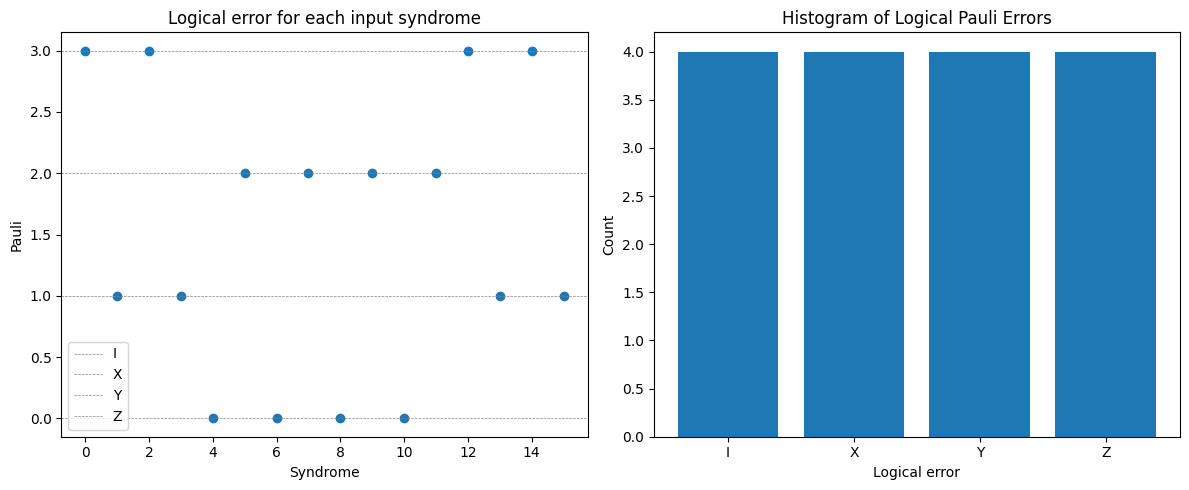

In [91]:
# Deterministic sweep: logical error for each syndrome given a fixed fault path
logical_error_dist_per_fault_path(code_513, fault_path=str_to_pauli(error), syndrome_error=syndrome_error)

## 5. Monte Carlo Simulation & Plots

Run `monte_carlo_new` for every input syndrome and visualise the logical error probability distribution.

The stacked bar chart shows P(X), P(Y), P(Z) for each input syndrome. P(I) = 1 - P(X) - P(Y) - P(Z) is the probability of no logical error (not plotted).

In [63]:
# --- Run MC for all syndromes ---
n_syn = code.n_syndromes
probs_new = np.zeros((n_syn, 4))

for s in range(n_syn):
    counts_L, _ = monte_carlo_new(code, p=p_val, q=q_val, s_in=s,
                                   n_samples=N_SAMPLES, seed=42 + s)
    probs_new[s] = counts_L / counts_L.sum()
    print(f's_in={s:2d}  P(I)={probs_new[s,0]:.6f}  P(X)={probs_new[s,1]:.6f}  '
          f'P(Y)={probs_new[s,2]:.6f}  P(Z)={probs_new[s,3]:.6f}')

s_in= 0  P(I)=0.999780  P(X)=0.000020  P(Y)=0.000040  P(Z)=0.000160
s_in= 1  P(I)=0.963420  P(X)=0.012620  P(Y)=0.002600  P(Z)=0.021360
s_in= 2  P(I)=0.963060  P(X)=0.021800  P(Y)=0.002880  P(Z)=0.012260
s_in= 3  P(I)=0.963040  P(X)=0.002780  P(Y)=0.012760  P(Z)=0.021420
s_in= 4  P(I)=0.964040  P(X)=0.020660  P(Y)=0.003320  P(Z)=0.011980
s_in= 5  P(I)=0.962660  P(X)=0.021900  P(Y)=0.012540  P(Z)=0.002900
s_in= 6  P(I)=0.953680  P(X)=0.021080  P(Y)=0.021940  P(Z)=0.003300
s_in= 7  P(I)=0.961120  P(X)=0.012680  P(Y)=0.023260  P(Z)=0.002940
s_in= 8  P(I)=0.963140  P(X)=0.012480  P(Y)=0.002920  P(Z)=0.021460
s_in= 9  P(I)=0.952000  P(X)=0.002820  P(Y)=0.023120  P(Z)=0.022060
s_in=10  P(I)=0.961100  P(X)=0.022620  P(Y)=0.013160  P(Z)=0.003120
s_in=11  P(I)=0.963140  P(X)=0.002860  P(Y)=0.021960  P(Z)=0.012040
s_in=12  P(I)=0.962860  P(X)=0.003100  P(Y)=0.012380  P(Z)=0.021660
s_in=13  P(I)=0.962240  P(X)=0.002540  P(Y)=0.022900  P(Z)=0.012320
s_in=14  P(I)=0.963060  P(X)=0.012040  P(Y)=0.02

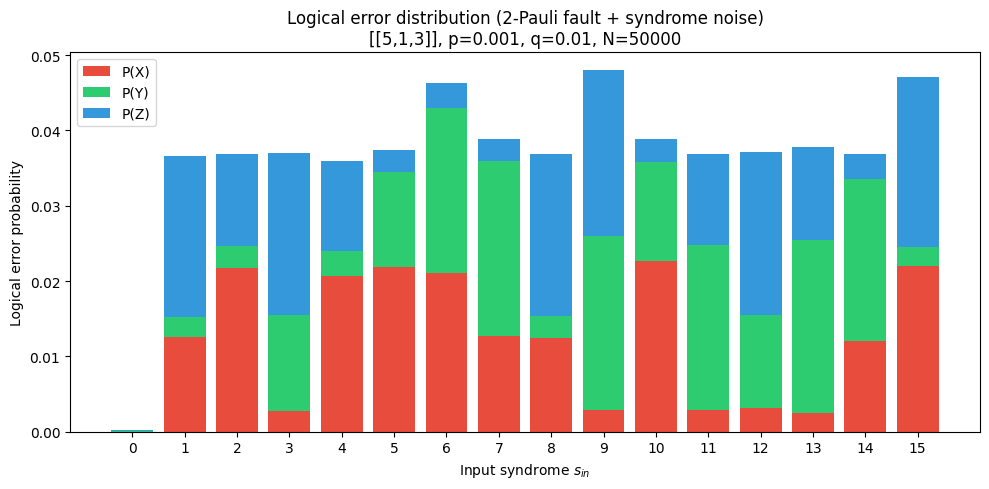


Average logical error rate across all syndromes: 0.036801


In [64]:
# --- Stacked bar chart: logical error probability per syndrome ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(n_syn)

ax.bar(x, probs_new[:, 1], label='P(X)', color='#e74c3c')
ax.bar(x, probs_new[:, 2], bottom=probs_new[:, 1], label='P(Y)', color='#2ecc71')
ax.bar(x, probs_new[:, 3], bottom=probs_new[:, 1] + probs_new[:, 2],
       label='P(Z)', color='#3498db')

ax.set_xlabel('Input syndrome $s_{in}$')
ax.set_ylabel('Logical error probability')
ax.set_title(f'Logical error distribution (2-Pauli fault + syndrome noise)\n'
             f'{code.name}, p={p_val}, q={q_val}, N={N_SAMPLES}')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

# --- Summary ---
total_error_rate = 1 - probs_new[:, 0].mean()
print(f"\nAverage logical error rate across all syndromes: {total_error_rate:.6f}")